In [ ]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)
print(torch.cuda.get_arch_list())


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# import numpy as np
# seed = 123
# torch.manual_seed(seed)
# np.random.seed(seed)
#
# torch.cuda.manual_seed(seed)
# torch.cuda.manual_seed_all(seed)
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

In [ ]:
exclude_rgb_vis=False
exclude_weather_features=True
exclude_canopy_temp=True
dataset_name = "stratified_train_test_datasets_v3_all_interpolated.xlsx"

In [ ]:
window_size = 30
pad_value = 0

In [ ]:
from features import *

vi_features = get_vi_features(exclude_rgb_vis=exclude_rgb_vis)
weather_features = get_weather_features(exclude=exclude_weather_features)
canopy_temp_features = get_canopy_temp_features(exclude=exclude_canopy_temp)
features = vi_features + weather_features + canopy_temp_features

output_variable = get_output_variable()

In [ ]:
# Loading saved training test
train_df = pd.read_excel(f"data/{dataset_name}", sheet_name='Train')
test_df = pd.read_excel(f"data/{dataset_name}", sheet_name='Test')

sns.kdeplot(train_df[output_variable], label='Train')
sns.kdeplot(test_df[output_variable], label='Test')
plt.legend()
plt.title("Train vs Test Yield Distribution")

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

scaler_X = StandardScaler()
scaler_y = RobustScaler()

# Fit on training features and yield only
scaler_X.fit(train_df[features])
scaler_y.fit(train_df[[output_variable]])

train_df_scaled = train_df.copy()
test_df_scaled  = test_df.copy()

# --- Scaled features and target variable---
train_df_scaled[features] = scaler_X.transform(train_df[features])
train_df_scaled[output_variable] = scaler_y.transform(train_df[[output_variable]])

test_df_scaled[features] = scaler_X.transform(test_df[features])
test_df_scaled[output_variable] = scaler_y.transform(test_df[[output_variable]])

In [ ]:

num_na_rows = train_df_scaled.isna().any(axis=1).sum()
print(f"train_df_scaled Rows with at least one NaN: {num_na_rows}")

num_na_rows = test_df_scaled.isna().any(axis=1).sum()
print(f"test_df_scaled Rows with at least one NaN: {num_na_rows}")


In [ ]:
# print(X_test_scaled.shape)

In [ ]:
from train_eval_functions import train_data, evaluate_model
import optuna
from torch.utils.data import DataLoader
from helper import make_progressive_windows
from model_definitions import GRUModel, LSTMModel
from vi_dataset import VIDataset

In [ ]:

cols_to_pad = canopy_temp_features
train_df_scaled[cols_to_pad] = train_df_scaled[cols_to_pad].fillna(pad_value)
test_df_scaled[cols_to_pad] = test_df_scaled[cols_to_pad].fillna(pad_value)


In [ ]:

X_train_scaled, y_train_scaled, valid_length_train, no_days_train = make_progressive_windows(
        dataframe=train_df_scaled,
        features=features,
        output_variable=output_variable,
        window_size=window_size,
        pad_value=pad_value)

X_test_scaled, y_test_scaled, valid_length_test, no_days_test  = make_progressive_windows(
    dataframe=test_df_scaled,
    features=features,
    output_variable=output_variable,
    window_size=window_size,
    pad_value=pad_value)

train_dataset = VIDataset(X_train_scaled, y_train_scaled, valid_length_train)
test_dataset = VIDataset(X_test_scaled, y_test_scaled, valid_length_test)


In [ ]:
from train_eval_functions import validation_with_test_LSTM

epochs = 1000

def hyper_param_objective(trial):
    hidden_size = trial.suggest_categorical('hidden_size', [8, 16, 32 , 64])
    num_layers = trial.suggest_categorical('num_layers', [1, 2, 3])
    dropout = trial.suggest_float('dropout', 0.0,  0.5)
    lr = trial.suggest_float('lr', 1e-4,  1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-10, 1e-3, log=True)
    # bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [8, 16, 32, 64])

    mean_r2 = validation_with_test_LSTM(
        trial_id = trial.number,
        train_dataset = train_dataset,
        test_dataset = test_dataset,
        features = features,
        scaler_y=scaler_y,
        batch_size= batch_size,
        num_epochs=epochs,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout,
        learning_rate=lr,
        weight_decay=weight_decay,
        hyper_param_criterion_method="L1Loss")
    return mean_r2

In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(hyper_param_objective, n_trials=180)

print(f"Best R²: {study.best_value:.4f}")
print("Best hyperparameters:", study.best_params)

In [ ]:
# =============================================
#  Train the best model with best hyper params
# =============================================
from model_definitions import LSTMModel


# saved as /best_lstm_models/best_model_hyper_param_2.pth
# Test R²: 0.3636, Test MSE: 0.0479, Test MAE: 0.1732, max R²: 0.5174
# Dataset: v3
# Features: only All the VIs  in v3 dataset
# Masking/Length in LSTM: False;  Make sure LSTM model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
# best_lstm_params = {'hidden_size': 8, 'num_layers': 3, 'dropout': 0.27260383547219424, 'lr': 0.009285505811941576, 'weight_decay': 3.165581570390733e-07, 'batch_size': 8}

# saved as /best_lstm_models/best_model_hyper_param_3.pth
# Dataset: v3
# Test R²: 0.2652, Test MSE: 0.0553, Test MAE: 0.1891, max R²: 0.49553966522216797
# Features: Vis + Lepton temp  in v3 dataset
# Masking/Length in LSTM: False;  Make sure LSTM model does not use lengths in the forward function
# Pad = 0
# criterion_method = L1 Loss
best_lstm_params = {'hidden_size': 16, 'num_layers': 2, 'dropout': 0.4248770561325045, 'lr': 0.0033221301193583374, 'weight_decay': 2.3506292058834832e-08, 'batch_size': 8}

best_model = LSTMModel(
    input_size=len(features),
    hidden_size=best_lstm_params['hidden_size'],
    num_layers=best_lstm_params['num_layers'],
    output_size=1,
    dropout=best_lstm_params['dropout']).to(device)




In [ ]:
train_loader  = DataLoader(train_dataset, batch_size=best_lstm_params['batch_size'], shuffle=True)
test_loader    = DataLoader(test_dataset, batch_size=best_lstm_params['batch_size'], shuffle=False)

In [ ]:

# Optional: Train again with best hyper parameters

epochs = 200
criterion_method="L1Loss"

train_losses = train_data(
            model = best_model,
            model_train_loader= train_loader,
            num_epochs = epochs,
            learning_rate = best_lstm_params['lr'],
            weight_decay = best_lstm_params['weight_decay'],
            hyper_param_criterion_method = criterion_method,
            file_save_name ="best_model_gru2.pth",
            early_stopping = False,
        )


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, 200+1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.show()

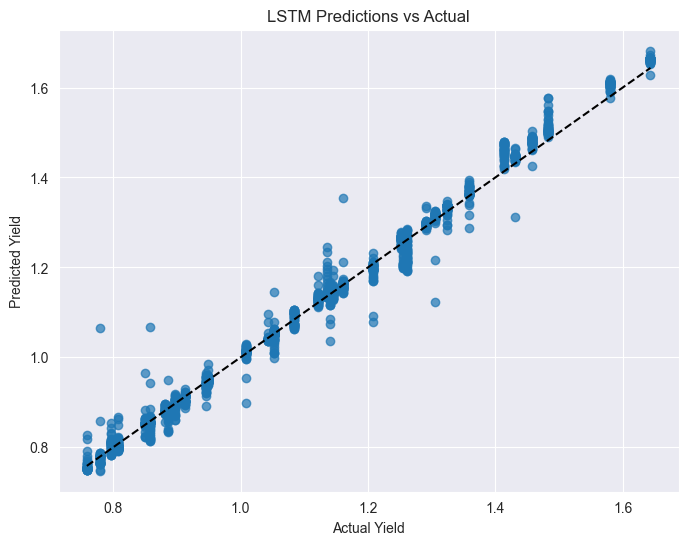

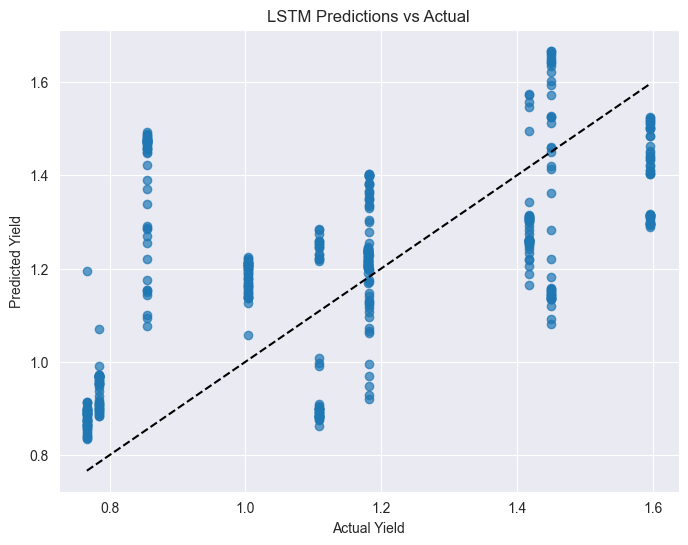

Train R²: 0.9902, Train MSE: 0.0006, Train MAE: 0.0145
Test R²: 0.2652, Test MSE: 0.0553, Test MAE: 0.1891


In [23]:
# from train_eval_functions import evaluate_model

best_model.load_state_dict(torch.load("best_lstm_models/best_model_hyper_param_3.pth", map_location=device))

# Training metrics
r2_train, mse_train, mae_train = evaluate_model(best_model, train_loader, output_variable_scaler=scaler_y, do_inverse_transform= True, plot_pred_vs_true=True)
# Test metrics
r2_test, mse_test, mae_test = evaluate_model(best_model, test_loader, output_variable_scaler=scaler_y, do_inverse_transform= True, plot_pred_vs_true=True)


print(f'Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}, Train MAE: {mae_train:.4f}')
print(f'Test R²: {r2_test:.4f}, Test MSE: {mse_test:.4f}, Test MAE: {mae_test:.4f}')


In [24]:
from helper import filter_window_data_by_length

total_n_days = 46 # (from may 1st to June 15th)

test_r2 = []
test_mse = []
test_mae = []
for filter_day in range(1, total_n_days + 1):
    print(f"day: {filter_day}")

    X_train_scaled_filtered, y_train_scaled_filtered, lengths_train_filtered = filter_window_data_by_length(
    X_train_scaled, y_train_scaled, valid_length_train, no_days_train, filter_day
    )

    # test
    X_test_scaled_filtered, y_test_scaled_filtered, lengths_test_filtered = filter_window_data_by_length(
        X_test_scaled, y_test_scaled, valid_length_test, no_days_test, filter_day
    )

    train_dataset_filtered = VIDataset(X_train_scaled_filtered, y_train_scaled_filtered, lengths_train_filtered)
    test_dataset_filtered = VIDataset(X_test_scaled_filtered, y_test_scaled_filtered, lengths_test_filtered)

    train_loader_filtered  = DataLoader(train_dataset_filtered, batch_size=best_lstm_params['batch_size'], shuffle=True)
    test_loader_filtered    = DataLoader(test_dataset_filtered, batch_size=best_lstm_params['batch_size'], shuffle=False)

    # Training metrics
    r2_train_filtered, mse_train_filtered, mae_train_filtered = evaluate_model(best_model, train_loader_filtered, output_variable_scaler=scaler_y, do_inverse_transform = True,  plot_pred_vs_true=False)
    # Test metrics
    r2_test_filtered, mse_test_filtered, mae_test_filtered = evaluate_model(best_model, test_loader_filtered, output_variable_scaler=scaler_y, do_inverse_transform = True,  plot_pred_vs_true=False)

    print(f'Train R²: {r2_train_filtered:.4f}, Train MSE: {mse_train_filtered:.4f}, Train MAE: {mae_train_filtered:.4f}')
    print(f'Test R²: {r2_test_filtered:.4f}, Test MSE: {mse_test_filtered:.4f}, Test MAE: {mae_test_filtered:.4f}')
    test_r2.append(r2_test_filtered)
    test_mse.append(mse_test_filtered)
    test_mae.append(mae_test_filtered)


day: 1
Train R²: 0.8439, Train MSE: 0.0090, Train MAE: 0.0703
Test R²: 0.2154, Test MSE: 0.0591, Test MAE: 0.1839
day: 2
Train R²: 0.9492, Train MSE: 0.0029, Train MAE: 0.0461
Test R²: 0.2413, Test MSE: 0.0571, Test MAE: 0.1902
day: 3
Train R²: 0.9820, Train MSE: 0.0010, Train MAE: 0.0254
Test R²: 0.3124, Test MSE: 0.0518, Test MAE: 0.1663
day: 4
Train R²: 0.9875, Train MSE: 0.0007, Train MAE: 0.0198
Test R²: 0.3342, Test MSE: 0.0501, Test MAE: 0.1591
day: 5
Train R²: 0.9888, Train MSE: 0.0006, Train MAE: 0.0169
Test R²: 0.3251, Test MSE: 0.0508, Test MAE: 0.1588
day: 6
Train R²: 0.9894, Train MSE: 0.0006, Train MAE: 0.0162
Test R²: 0.3126, Test MSE: 0.0518, Test MAE: 0.1552
day: 7
Train R²: 0.9913, Train MSE: 0.0005, Train MAE: 0.0152
Test R²: 0.2932, Test MSE: 0.0532, Test MAE: 0.1673
day: 8
Train R²: 0.9922, Train MSE: 0.0004, Train MAE: 0.0144
Test R²: 0.2651, Test MSE: 0.0553, Test MAE: 0.1768
day: 9
Train R²: 0.9926, Train MSE: 0.0004, Train MAE: 0.0142
Test R²: 0.2385, Test MSE:

In [25]:
import numpy as np

print(np.mean(test_r2))
print(np.min(test_r2))
print(np.max(test_r2))

print(np.mean(test_mse))
print(np.max(test_mse))
print(np.min(test_mse))

print(np.mean(test_mae))
print(np.max(test_mae))
print(np.min(test_mae))

0.26516164515329443
0.04291844367980957
0.49553966522216797
0.05532618522967981
0.07205893844366074
0.03798095881938934


In [ ]:
from plots import plot_r2, plot_mse

plot_r2(test_r2, total_n_days)
plot_mse(test_mse, total_n_days)

In [ ]:
# save model
torch.save(best_model, "best_gru_models/best_model_full_3.pth")

# save Scalers for future predictions
import joblib

joblib.dump(scaler_X, "best_gru_models/scalers/scaler_X_3.save")
joblib.dump(scaler_y, "best_gru_models/scalers/scaler_y_3.save")